### 🔢 Study Session 4 — Plot Actual vs Predicted with red dashed y=x line; save via save_and_log_plot()

In [ ]:
# --- 1. Import libraries ---
import os
import sys
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

# Manually define the correct project root path based on your previous output
CORRECT_PROJECT_ROOT = "/home/rtackett/projects/Masters-level-DIY-Data-Science-Curriculum-ai-Era-/ds-zero-to-one"

# Set CWD
try:
    os.chdir(CORRECT_PROJECT_ROOT)
    print(f"✅ CWD successfully set to: {os.getcwd()}")

    # Add to sys.path for module imports (src.helpers)
    if CORRECT_PROJECT_ROOT not in sys.path:
        sys.path.append(CORRECT_PROJECT_ROOT)
        print("✅ Added project root to sys.path.")

except FileNotFoundError:
    print("❌ CRITICAL ERROR: The manually defined project path does not exist.")
    sys.exit(1)

# --- 2. Load dataset saved previously above from seaborn's GitHub mirror ---
# NOTE: Path adjusted to be relative to the Project Root CWD
df = duckdb.query("""
    SELECT * FROM read_csv_auto('data/processed/tips_cleaned.csv')
""").df()

df.info

In [ ]:
df.describe()

## 🧮 Actual vs Predicted Tips — ELI5

Each blue dot = one restaurant bill.  
- The **x-axis** shows the *actual tip (\$)*.  
- The **y-axis** shows the *predicted tip (\$)* from our regression model.  
- The **red dashed line** shows *perfect predictions* — if the model were flawless, every dot would sit right on that line.  

**Interpretation:**
- Dots **below** the red line → model *overpredicted* (it thought tips would be higher).  
- Dots **above** the line → model *underpredicted* (actual tips were higher).  

💡 The closer the dots are to the red line, the more accurate our model is.  
But since tipping is human behavior, some scatter is expected!


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# 1️⃣ Define features (independent variables) and target (dependent variable)
X = df[['bill_total_usd', 'party_size']]  # predictors
y = df['tip_usd']                         # actual tips

# 2️⃣ Fit the model
model = LinearRegression()
model.fit(X, y)

# 3️⃣ Predict tip amounts
y_pred = model.predict(X)

# 4️⃣ Quick check of model fit
print(f"R²: {r2_score(y, y_pred):.3f}")
print(f"Slope coefficients: {dict(zip(X.columns, model.coef_))}")
print(f"Intercept: {model.intercept_:.3f}")


R²: 0.468
Slope coefficients: {'bill_total_usd': np.float64(0.09271333683226955), 'party_size': np.float64(0.19259779439078675)}
Intercept: 0.669


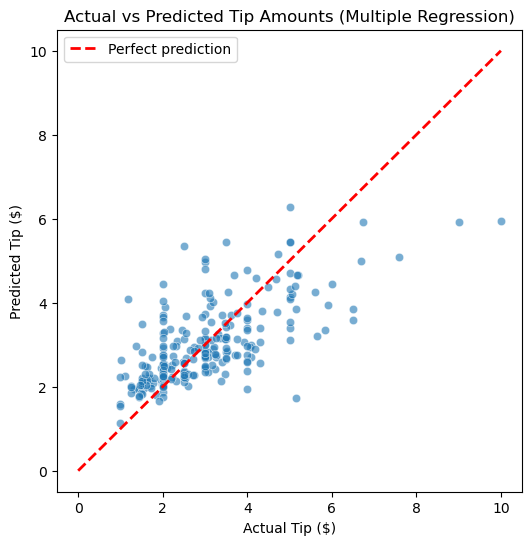

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from src.helpers import save_and_log_plot

# 1️⃣ Generate scatter of actual vs predicted
fig, ax = plt.subplots(figsize=(6, 6))
sns.scatterplot(x=y, y=y_pred, ax=ax, alpha=0.6)

# 2️⃣ Add the y=x reference line (perfect prediction)
max_val = max(y.max(), y_pred.max())
ax.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect prediction')

# 3️⃣ Label & title
ax.set_xlabel("Actual Tip ($)")
ax.set_ylabel("Predicted Tip ($)")
ax.set_title("Actual vs Predicted Tip Amounts (Multiple Regression)")
ax.legend()

# 4️⃣ Save and log plot
# save_and_log_plot(
#     ax,
#     "reports/figures/actual_vs_predicted_tips.png",
#     df=df_enc,
#     chart_type="scatter",
#     library="matplotlib",
#     x="actual_tip",
#     y="predicted_tip",
#     dataset_name="tips_cleaned",
#     dataset_path="data/processed/tips_cleaned.csv",
#     notebook="notebooks/04B_Multiple_Regression_Model_Evaluation.ipynb",
#     notes="Session 4 regression evaluation: actual vs predicted scatter",
#     timestamped=True
# )


In [8]:
from src.helpers import save_and_log_plot

save_and_log_plot(
    ax,
    "reports/figures/actual_vs_predicted_tips.png",
    df=df,
    chart_type="scatter",
    library="matplotlib",
    x="actual_tip",
    y="predicted_tip",
    dataset_name="tips_cleaned",
    dataset_path="data/processed/tips_cleaned.csv",
    notebook="notebooks/04B_Multiple_Regression_Model_Evaluation.ipynb",
    notes="Actual vs predicted tip scatter with red dashed y=x reference line",
    timestamped=True
)


✅ Saved Seaborn Axes figure to: reports/figures/actual_vs_predicted_tips_2025-10-24_1118.png
📝 Logged metadata → reports/figures/actual_vs_predicted_tips_2025-10-24_1118.json


(PosixPath('reports/figures/actual_vs_predicted_tips_2025-10-24_1118.png'),
 PosixPath('reports/figures/actual_vs_predicted_tips_2025-10-24_1118.json'))

In [ ]:
#7 Plot residuals (y - y_pred) vs predicted; add horizontal line at 0.

## 🪞 Residuals vs Predicted Tips — ELI5

Each blue dot shows how far off our model was for a given prediction:  
- The **x-axis** shows what the model *predicted*.  
- The **y-axis** shows the *residual* — the difference between the real tip and the model’s guess.

The **red dashed line** represents *zero error*.  
If the dots are randomly scattered around it (no clear pattern), that’s great — the model is behaving fairly.  

💡 Patterns or curves in residuals can mean:
- The model missed a variable.
- A nonlinear relationship exists.
- Or variance grows with bill size (a sign of heteroscedasticity).

Each blue dot = one restaurant bill.  
- **x-axis:** the model’s *predicted tip ($)*  
- **y-axis:** the *residual* — how far off the model was  
  (Residual = Actual Tip − Predicted Tip)

The **red dashed line** shows *zero error*.  
- Dots **above** → model *underpredicted* (real tip higher).  
- Dots **below** → model *overpredicted* (guessed too high).  

✅ Ideally: dots are randomly scattered around the red line — no pattern.  
That means the model’s mistakes are random (a healthy sign).

⚠️ If you see patterns or “fan shapes,” the model might be missing something important.

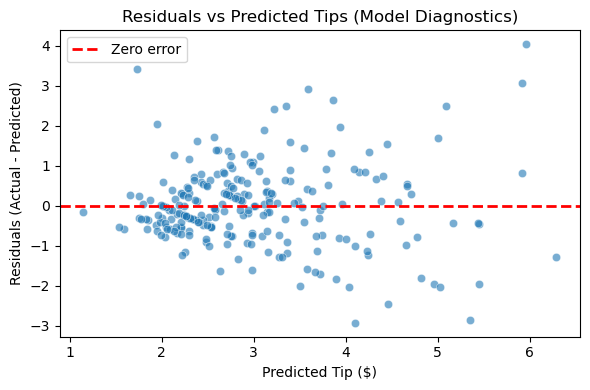

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Compute residuals
residuals = y - y_pred

# 2. Create scatter plot of residuals vs predicted values
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, ax=ax)

# 3. Add reference line at y=0
ax.axhline(0, color='red', linestyle='--', linewidth=2, label='Zero error')

# 4. Labels and title
ax.set_xlabel("Predicted Tip ($)")
ax.set_ylabel("Residuals (Actual - Predicted)")
ax.set_title("Residuals vs Predicted Tips (Model Diagnostics)")
ax.legend()

plt.tight_layout()
plt.show()


## 🧩 ELI5: What This Residual Plot Means

This chart checks how evenly our model makes mistakes.

- Each **blue dot** is one restaurant bill.  
- The **x-axis** shows what the model *predicted* the tip would be.  
- The **y-axis** shows how *wrong* the model was —  
  (Residual = Actual Tip − Predicted Tip).  
- The **red dashed line** is where the model would be *exactly right*.

If dots are scattered randomly above and below the red line, that means our model’s errors are nicely random — it’s not consistently guessing too high or too low.

### ⚠️ What We Notice
As the predicted tips get bigger (dots further right), the errors spread out a bit more.  
That’s called **heteroscedasticity** (het-er-oh-sked-AST-uh-sit-ee) — a fancy word meaning **the model’s mistakes grow when predictions get larger**.

### 🎯 In Plain English
Our model does well for small and medium tips,  
but its guesses for big tips can swing wide — sometimes too high, sometimes too low.  

That’s totally normal in real-world data,  
but it means the model is **less confident** for large bills.

### 🍦 Analogy
Imagine scooping ice cream:  
If every scoop should be the same size, but big cones get messy scoops and small cones get neat ones —  
that’s heteroscedasticity!


In [10]:
from src.helpers import save_and_log_plot

save_and_log_plot(
    ax,
    "reports/figures/residuals_vs_predicted_tips.png",
    df=df,
    chart_type="scatter",
    library="matplotlib",
    x="predicted_tip",
    y="residual",
    dataset_name="tips_cleaned",
    dataset_path="data/processed/tips_cleaned.csv",
    notebook="notebooks/04B_Multiple_Regression_Model_Evaluation.ipynb",
    notes="Residuals vs predicted tips with horizontal line at zero",
    timestamped=True
)


✅ Saved Seaborn Axes figure to: reports/figures/residuals_vs_predicted_tips_2025-10-24_1336.png
📝 Logged metadata → reports/figures/residuals_vs_predicted_tips_2025-10-24_1336.json


(PosixPath('reports/figures/residuals_vs_predicted_tips_2025-10-24_1336.png'),
 PosixPath('reports/figures/residuals_vs_predicted_tips_2025-10-24_1336.json'))

#### Opposite idea: homoscedascity

✅ Saved homoscedastic dataset to: /home/rtackett/ds-zero-to-one/data/processed/tips_homoscedastic.csv
R²: 0.903
Slope ≈ 0.121, Intercept ≈ 0.854, Noise σ ≈ 0.8


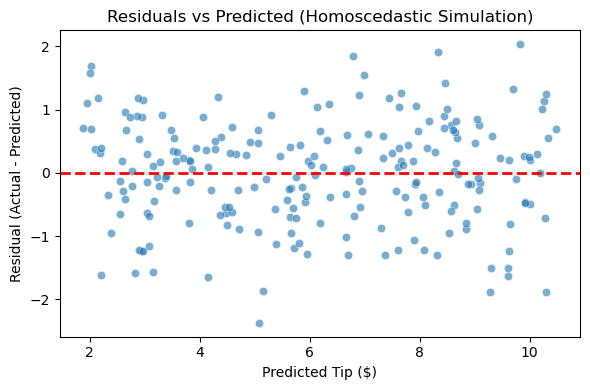

✅ Saved Seaborn Axes figure to: reports/figures/residuals_vs_predicted_tips_HOMOSCEDASTIC_2025-10-24_1424.png
📝 Logged metadata → reports/figures/residuals_vs_predicted_tips_HOMOSCEDASTIC_2025-10-24_1424.json
📝 Logged plot via save_and_log_plot().


In [11]:
# --- Generate a homoscedastic "tips" dataset, save it, and verify with residual plot ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Reproducibility
rng = np.random.default_rng(42)

# 1) Simulate features
n = 220
bill_total_usd = rng.uniform(8, 80, size=n)           # restaurant bills from $8 to $80
party_size     = rng.integers(1, 6, size=n)            # 1–5 people (not used in y, but realistic)
true_intercept = 0.9
true_slope     = 0.12

# 2) Homoscedastic noise (constant variance)
sigma = 0.80                                          # same std no matter the bill size
eps   = rng.normal(0, sigma, size=n)

# 3) Linear relationship with constant-variance noise
tip_usd = true_intercept + true_slope * bill_total_usd + eps
tip_usd = np.clip(tip_usd, 0, None)                    # no negative tips

# 4) Put in a DataFrame with familiar columns
df_homo = pd.DataFrame({
    "bill_total_usd": bill_total_usd,
    "tip_usd": tip_usd,
    "party_size": party_size
})
df_homo["tip_pct"] = (df_homo["tip_usd"] / df_homo["bill_total_usd"]).clip(0, 1)

# 5) Save to your repo (adjust repo_root if needed)
repo_root = Path.home() / "ds-zero-to-one"
out_csv = repo_root / "data" / "processed" / "tips_homoscedastic.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
df_homo.to_csv(out_csv, index=False)
print(f"✅ Saved homoscedastic dataset to: {out_csv}")

# 6) Fit a simple regression to verify residuals look homoscedastic
X = df_homo[["bill_total_usd"]]   # single predictor
y = df_homo["tip_usd"]

model = LinearRegression().fit(X, y)
y_pred = model.predict(X)
residuals = y - y_pred

print(f"R²: {r2_score(y, y_pred):.3f}")
print(f"Slope ≈ {model.coef_[0]:.3f}, Intercept ≈ {model.intercept_:.3f}, Noise σ ≈ {sigma}")

# 7) Residuals vs Predicted (should look evenly scattered around 0 with similar spread)
fig, ax = plt.subplots(figsize=(6,4))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.6, ax=ax)
ax.axhline(0, color="red", ls="--", lw=2)
ax.set_xlabel("Predicted Tip ($)")
ax.set_ylabel("Residual (Actual - Predicted)")
ax.set_title("Residuals vs Predicted (Homoscedastic Simulation)")
plt.tight_layout()
plt.show()

# 8) (Optional) Save & log with your helper if available
try:
    from src.helpers import save_and_log_plot
    save_and_log_plot(
        ax,
        "reports/figures/residuals_vs_predicted_tips_HOMOSCEDASTIC.png",
        df=df_homo,
        chart_type="scatter",
        library="matplotlib",
        x="predicted_tip",
        y="residual",
        dataset_name="tips_homoscedastic",
        dataset_path=str(out_csv.relative_to(repo_root)),
        notebook="notebooks/04B_Multiple_Regression_Model_Evaluation.ipynb",
        notes="Homoscedastic simulation residuals plot",
        timestamped=True
    )
    print("📝 Logged plot via save_and_log_plot().")
except Exception as e:
    print(f"(Optional logging skipped) Reason: {e.__class__.__name__}: {e}")


#### Variance Inflation Factor (VIF)

## 🔍 Multicollinearity (VIF) — ELI5

VIF checks if our predictor variables (like bill size and party size) are too similar to each other.

- **VIF ≈ 1** → variables are independent (good!)
- **VIF between 5 and 10** → some overlap (watch out)
- **VIF > 10** → variables may be duplicating information (bad)

Why this matters:
If predictors overlap too much, the model can’t tell which one really drives tips —  
it’s like having two thermometers giving almost the same reading and trying to decide which is more “important.”

In our dataset, if `bill_total_usd` and `party_size` both rise together, their VIFs might climb —  
meaning we may not need both to explain tips.


In [13]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Use the same predictors you used in your regression
X_vif = df[['bill_total_usd', 'party_size']].copy()

# 1️⃣ Add a constant (required for VIF)
X_vif = sm.add_constant(X_vif)

# 2️⃣ Compute VIF for each feature
vif_data = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

display(vif_data)


,Variable,VIF
0,const,8.904095
1,bill_total_usd,1.557586
2,party_size,1.557586


In [14]:
vif_data = pd.DataFrame({
    "Variable": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})


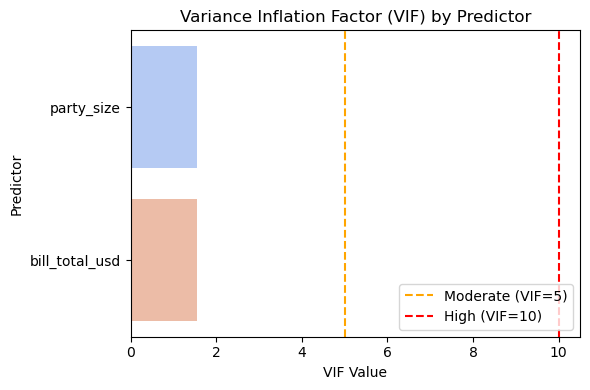

In [16]:
# --- Visualize VIF values for all predictors ---
import matplotlib.pyplot as plt
import seaborn as sns

# Drop constant term if present
vif_plot = vif_data[vif_data["Variable"] != "const"].copy()

# Sort by VIF descending
vif_plot = vif_plot.sort_values("VIF", ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(
    data=vif_plot,
    y="Variable",
    x="VIF",
    hue="Variable",          # <- add hue
    dodge=False,             # ensures one bar per variable
    palette="coolwarm",
    legend=False,            # hides duplicate color legend
    ax=ax
)


# Highlight "risky" VIF thresholds
ax.axvline(5, color="orange", linestyle="--", label="Moderate (VIF=5)")
ax.axvline(10, color="red", linestyle="--", label="High (VIF=10)")

# Labels and title
ax.set_title("Variance Inflation Factor (VIF) by Predictor")
ax.set_xlabel("VIF Value")
ax.set_ylabel("Predictor")
ax.legend(loc="lower right")
plt.tight_layout()

plt.show()


## 🧠 Understanding VIF (Variance Inflation Factor)

VIF shows how much a variable’s importance is “inflated” because it overlaps with other predictors.

| **VIF Range** | **Meaning** | **Interpretation** |
|:--------------|:------------|:-------------------|
| **≈ 1** | No multicollinearity | Each predictor adds unique info. The model is stable. ✅ |
| **2 – 5** | Mild overlap | Some shared info, but fine for most use cases. ⚠️ |
| **5 – 10** | Moderate multicollinearity | Predictors are overlapping. Coefficients might change drastically with small data tweaks. 🧩 |
| **> 10** | Severe multicollinearity | Variables are duplicating each other. Remove or combine them to simplify the model. 🚨 |

💡 **Analogy:**  
If multiple predictors tell the same story (like three people describing the same movie in different words),  
the model gets confused about who’s responsible for the effect — that’s multicollinearity.
